## Preliminary Steps
Import all libraries or related functions.

In [2]:
# list of external dependencies
import os
import time
import numpy as np
from tqdm import trange
from functools import partial
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set JAX environment variables
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"
# Set environment variables to use alql 128 CPU cores
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=128'
os.environ['OMP_NUM_THREADS'] = '128'

import jax
import jax.numpy as jnp

## Cost Matrix Generation
The following code section controls the cost matrix generation.

In [3]:
@partial(jax.jit, static_argnums=(0, 1))
def cartesian_product_jax(n, N):
    ranges = [jnp.arange(n, dtype=jnp.int64)] * N
    grid = jnp.meshgrid(*ranges, indexing='ij')
    product = jnp.stack(grid, axis=-1).reshape(-1, N)
    return product

@partial(jax.jit, static_argnums=1)
def single_strong_coulomb_cost(index, N):
    """
    Computes the Strong Coulomb cost for indexed marginals
    """
    marginals_to_update = jax.random.choice(jax.random.PRNGKey(0), N, (2,), replace=False)
    i, j = marginals_to_update
    diff = jnp.abs(index[i] - index[j])
    return jnp.where(diff != 0, 2 / diff, jnp.inf)

@partial(jax.jit, static_argnums=1)
def single_weak_coulomb_cost(index, N):
    """
    Computes the Weak Coulomb cost for indexed marginals
    """
    marginals_to_update = jax.random.choice(jax.random.PRNGKey(0), N, (2,), replace=False)
    i, j = marginals_to_update
    diff = jnp.abs(index[i] - index[j])
    return jnp.where(diff != 0, 2 / diff, 1e+8)

@partial(jax.jit, static_argnums=1)
def single_euclidean_cost(index, N):
    """
    Computes the Euclidean cost for indexed marginals
    """
    marginals_to_update = jax.random.choice(jax.random.PRNGKey(0), N, (2,), replace=False)
    i, j = marginals_to_update
    diff = jnp.abs(index[i] - index[j])
    return jnp.where(diff != 0, diff**2, jnp.inf)

The following function computes the cost matrix

In [8]:
def compute_cost(n, N, single_cost, batch_size = None):
    """
    Computes the cost tensor of N marginal probability vectors that are n-discretized under specified single_cost function
    """
    start_time = time.time()
    shape = (n,) * N
    indices = cartesian_product_jax(n, N)
    if batch_size is None:
        batch_size = jnp.uint64(len(indices) // 10)
    C = jnp.zeros(shape)
    compute_cost_vmap = jax.vmap(single_cost, in_axes=(0, None))
    for batch_start in trange(0, len(indices), batch_size):
        batch_indices = indices[batch_start:jnp.uint64(batch_start + batch_size)]
        costs = compute_cost_vmap(batch_indices, N)
        C = C.at[tuple(batch_indices.T)].set(costs)
    end_time = time.time()
    return C, end_time - start_time

Let us store the $n\times n$ weak coulomb cost matrix $C$ using the above function. In this scenario, let us fix $n=500$ and $N=2$.

In [9]:
cost, elapsed_time = compute_cost(n=500,
                                  N=2,
                                  single_cost=single_weak_coulomb_cost)

100%|██████████| 10/10 [00:00<00:00, 59.09it/s]


Let us perform a sanity check on the generated cost matrix.

[[1.00000000e+08 2.00000000e+00 1.00000000e+00 ... 4.02414487e-03
  4.01606426e-03 4.00801603e-03]
 [2.00000000e+00 1.00000000e+08 2.00000000e+00 ... 4.03225806e-03
  4.02414487e-03 4.01606426e-03]
 [1.00000000e+00 2.00000000e+00 1.00000000e+08 ... 4.04040404e-03
  4.03225806e-03 4.02414487e-03]
 ...
 [4.02414487e-03 4.03225806e-03 4.04040404e-03 ... 1.00000000e+08
  2.00000000e+00 1.00000000e+00]
 [4.01606426e-03 4.02414487e-03 4.03225806e-03 ... 2.00000000e+00
  1.00000000e+08 2.00000000e+00]
 [4.00801603e-03 4.01606426e-03 4.02414487e-03 ... 1.00000000e+00
  2.00000000e+00 1.00000000e+08]]


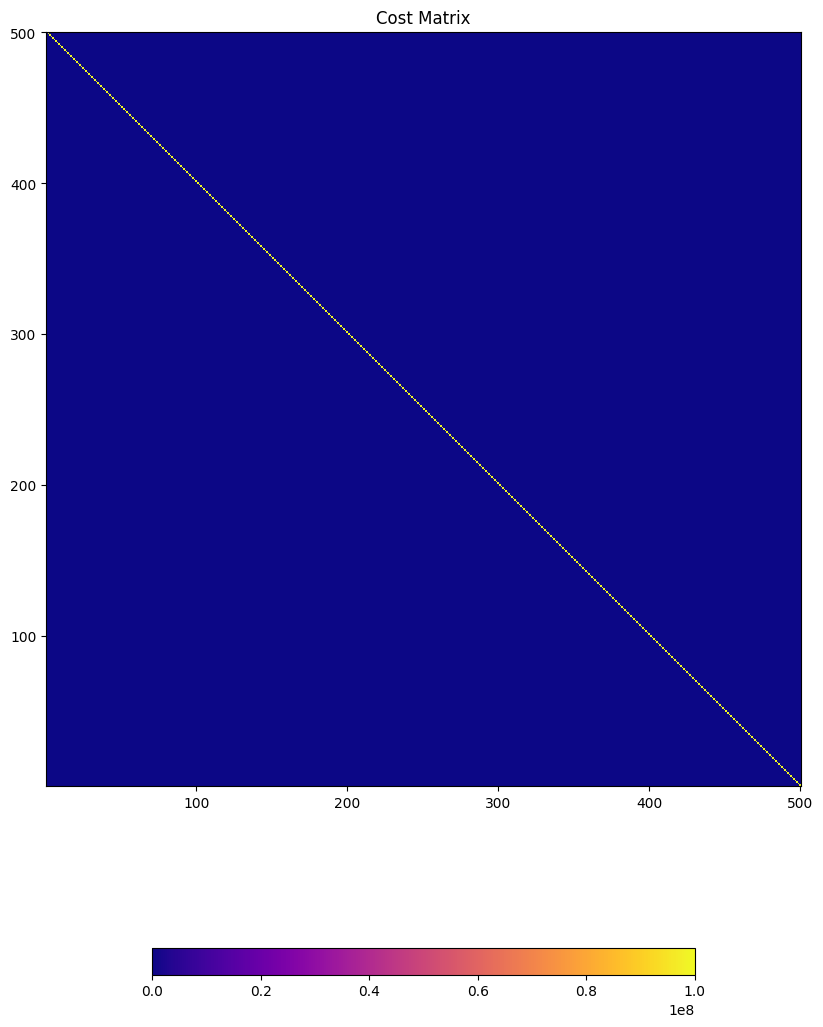

In [10]:
def plot_matrix(matrix, name: str) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(14,14))
    im = ax.imshow(matrix,
                   interpolation='nearest',
                   cmap="plasma",
                   extent=(0.5, np.shape(matrix)[0] + 0.5, 0.5, np.shape(matrix)[1] + 0.5))
    ax.set_title(name)  # Add title to each subplot (optional)
    # Adjust layout (optional)
    fig.colorbar(im, ax=ax, shrink=0.5, location="bottom")

print(cost)
plot_matrix(cost, "Cost Matrix")

## Marginal Distribution Generation
Let us generate two marginal probability vectors/distributions $\mu$ and $\nu$. We will take Gaussian measures of different parameters.

In [11]:
def compute_gaussian_marginal(lend, rend, n, locs, scales):
    """
    Generate a marginal probability vector in R^n that is supported on [lend, rend]
    The resulting vector is a linear combination of normal distributions with means=locs and standard deviations=scales
    """
    x = jnp.linspace(lend, rend, n)
    mu = jnp.zeros(n)
    for (loc, scale) in zip(locs, scales):
        mu += (norm.pdf(x,loc=loc, scale=scale))/len(locs)
    mu = mu / mu.sum()
    return mu

Take $\mu=N(1.5,0.5)$ and $\nu=N(2.5,0.9)+N(-2.75,0.7)$.

In [12]:
mu = compute_gaussian_marginal(-5, 5, n=500,
                               locs=[1.5],
                               scales=[0.5])
nu = compute_gaussian_marginal(-5, 5, n=500,
                               locs=[2.5,-2.75],
                               scales=[0.9,0.7])

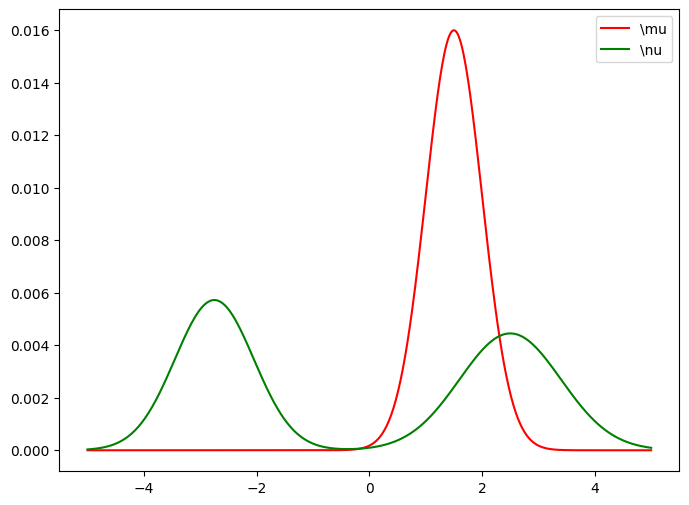

In [13]:
COLORS = ["red", "green", "blue", "orange", "purple"]

def plot_vectors(n: int, data: dict):
    """
    Plots vectors supported on [-5,5] with respect to labels.
    """
    x = np.linspace(-5, 5, n)
    fig = plt.figure(figsize=(8, 6))
    i = 0
    for label, vec in data.items():
        plt.plot(x, vec, label=rf'\{label}', color=COLORS[i])
        i += 1
    plt.legend()

plot_vectors(500, {"mu":mu, "nu":nu})

## Running Quadratic Entropy Regularization Algorithms
There are four algorithms that are tested for this purpose: cyclic projection, gradient descent, fixed point iteration, and stochastic gradient descent.

In [14]:
@jax.jit
def quadratic_compute_error(P: jnp.ndarray, a: jnp.ndarray, b: jnp.ndarray):
    """
    Computes maximum of two Frobenius norm as max(||P-a||, ||P-b||)
    """
    error_a = jnp.abs(P.sum(axis=1) - a).sum()
    error_b = jnp.abs(P.sum(axis=0) - b).sum()
    return jnp.maximum(error_a, error_b)

In [ ]:
# import all necessary external dependencies
import os, sys

@jax.jit
def quadratic_compute_error(P: jnp.ndarray, a: jnp.ndarray, b: jnp.ndarray):
    """
    Computes maximum of two Frobenius norm as max(||P-a||, ||P-b||)
    """
    error_a = jnp.abs(P.sum(axis=1) - a).sum()
    error_b = jnp.abs(P.sum(axis=0) - b).sum()
    return jnp.maximum(error_a, error_b)

@jax.jit
def sinkhorn_compute_error(vars: list, marginals: list, K: int):
    """
    Computes multi-marginal Frobenius norm
    """
    error_value = 0.0
    N = len(marginals)
    P = jnp.einsum(K, np.arange(N), *utils.get_all_arguments(vars), np.arange(N))
    for i in range(N):
      new_error = jnp.sum(jnp.abs(jnp.einsum(P, np.arange(N), [i]) - marginals[i]))
      error_value = jax.lax.select(error_value < new_error, new_error, error_value)
    return error_value

@jax.jit
def compute_P(vars: list, K: int) -> jnp.ndarray:
    """
    Computes a coupling tensor P for the Sinkhorn Algorithm
    """
    N = len(vars)
    return jnp.einsum(K, np.arange(N), *utils.get_all_arguments(vars), np.arange(N))


def shannon_sinkhorn(marginals, C, epsilon:float, convergence_error:float, max_iters: int):
    start_time = time.time()
    N = len(marginals)
    n = marginals[0].shape[0]
    vars = [jnp.ones(n) for _ in range(N)]
    K = jnp.exp(-C/epsilon) # Kernel tensor
    error = convergence_error*2
    iterations = 0
    for t in range(1, max_iters+1):
        for i in range(N):
            vars[i] = marginals[i] / (jnp.einsum(K, jnp.arange(N), *args))
        if error <= convergence_error:
            iterations = t
            break
    P = compute_P(vars, K)
    end_time = time.time()
    time_taken = end_time - start_time
    return P, error, iterations, time_taken

In [18]:
P, error, iterations, time_taken = shannon_sinkhorn(marginals=[mu, nu],
                             C=cost,
                             epsilon=1e-2,
                             convergence_error=1e-5,
                             max_iters=10000)

print(P)
plot_matrix(P, "Cyclic Projection Solution")

NameError: name 'args' is not defined